# Extracting Attention Maps

In [1]:
# Imports
from typing import Tuple, Dict, List
from torchvision import transforms
from PIL import Image, ImageDraw
import models.ResNetC as ResNetC
import matplotlib.pyplot as plt
import torch.nn.functional as F
import models.EffNet as EffNet
import models.PVTv2 as PVTv2
import models.ViT as ViT
import seaborn as sns
import torch

C:\Users\EuanH\anaconda3\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
C:\Users\EuanH\anaconda3\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.cuda.is_available()

True

## Helper functions

In [3]:
def get_attention_map(model, img):
    model.eval()
    with torch.no_grad():
        _ = model(img)

    if type(model) == ViT.ViTClassifier:
        return model.vit.encoder.layer[-1].self_attention_block.attn_weights
        
    img_h, img_w = img.shape[2], img.shape[3]
    results = {}

    # PVT v2 spatial resolution per stage (for 224px input)
    # stage1: /4, stage2: /8, stage3: /16, stage4: /32
    for stage_idx in range(model.num_stages):
        block = getattr(model, f"block{stage_idx + 1}")
        
        # Collect attention from every block in this stage, average them
        stage_attns = []
        for blk in block:
            attn = blk.attn.attn_weights  # (batch, heads, N_q, N_kv)
            # Average over heads, take mean over query tokens → (N_kv,)
            attn = attn[0].mean(dim=0).mean(dim=0)  # (N_kv,)
            stage_attns.append(attn)

        attn_map = torch.stack(stage_attns).mean(0)  # (N_kv,)

        # N_kv depends on sr_ratio — figure out spatial size from num tokens
        n_kv = attn_map.shape[0]
        h = w = int(n_kv ** 0.5)

        attn_map = attn_map.reshape(1, 1, h, w)
        attn_map = F.interpolate(attn_map, size=(img_h, img_w),
                                 mode='bilinear', align_corners=False).squeeze()

        # Normalise to [0, 1]
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-6)
        results[f"stage{stage_idx + 1}"] = attn_map

    return results

def get_resnet_feature_maps(model, img):
    feature_maps = {}
    hooks = []

    # Register a hook on each layer
    def make_hook(name):
        def hook(module, input, output):
            feature_maps[name] = output.detach()
        return hook

    hooks.append(model.layer1.register_forward_hook(make_hook("layer1")))
    hooks.append(model.layer2.register_forward_hook(make_hook("layer2")))
    hooks.append(model.layer3.register_forward_hook(make_hook("layer3")))
    hooks.append(model.layer4.register_forward_hook(make_hook("layer4")))

    model.eval()
    with torch.no_grad():
        _ = model(img)

    # Remove hooks after use — important, otherwise they persist and slow training
    for hook in hooks:
        hook.remove()

    return feature_maps


def visualise_resnet_feature_map(model, img_t, layer="layer4"):
    feature_maps = get_resnet_feature_maps(model, img_t)

    fmap = feature_maps[layer]              # (1, C, H, W)
    mean_activation = fmap.squeeze(0).mean(dim=0)  # (H, W)
    mean_activation = (mean_activation - mean_activation.min()) / \
                      (mean_activation.max() - mean_activation.min() + 1e-6)

    mean_activation = F.interpolate(
        mean_activation.unsqueeze(0).unsqueeze(0),
        size=(img_t.shape[2], img_t.shape[3]),
        mode="bilinear",
        align_corners=False
    ).squeeze()

    return mean_activation


In [4]:
# Load Image
img = Image.open("Dataset/cirsium arvense/original/medium occlusion/Cirsium arvense-16.jpg")
size = 50
mean = (0.5, 0.5, 0.5)
std = (0.5, 0.5, 0.5)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=size/100),
])

img_t = transform(img).unsqueeze(0).to(device)  # → (1, C, H, W)

In [22]:
# Visual Transformer
mdl = "PvTv2"
size= "25"

match mdl:
    case "ViT-B16":
        model = ViT.ViTClassifier(sample_img=img_t, num_classes=3, pretrained=False).to(device) 
        checkpoint = torch.load(f"Weights/vit_{size}_weights", map_location=device)
    case "PvTv2":
        model = PVTv2.pvt_v2_b0(num_classes=3, pretrained=None).to(device) 
        checkpoint = torch.load(f"Weights/pvtv2_{size}_weights", map_location=device)

    case "EfficientNet-B0":
        model = EffNet.EfficientNet.from_name("efficientnet-b0", in_channels=3, num_classes=3).to(device)
        model.load_state_dict(torch.load(f"Weights/efficient_{size}_weights", map_location=device))

    case "ResNet50":
        model = ResNetC.ResNet50(num_classes=3).to(device)
        model.load_state_dict(torch.load(f"Weights/resnet_{size}_weights", map_location=device))
        
    case _:
        raise TypeError("Incorrect model choice")
        


# Display attention Map

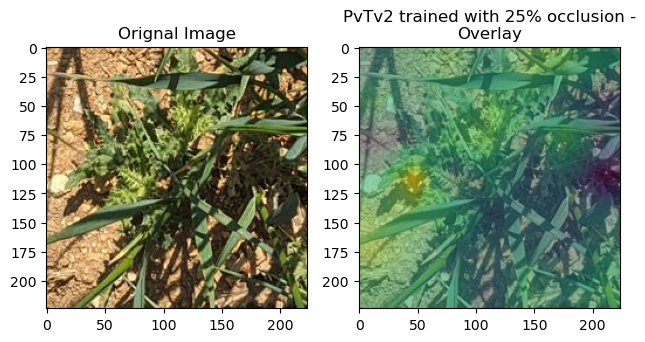

In [23]:
# CLS token attends to all patches — the most useful map for classification
from textwrap import wrap
if mdl == "ViT-B16" or mdl == "PvTv2":
    attn = get_attention_map(model, img_t)
    pth = "am"
else:
    pth = "fm"

fig, axes = plt.subplots(1, 2)
axes.flatten()
axes[0].imshow(img)
axes[0].set_title("Orignal Image")
axes[1].set_title("\n".join(wrap(f"{mdl} trained with {size}% occlusion - Overlay", 40)))

img_np = img_t.squeeze().permute(1, 2, 0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-6)
axes[1].imshow(img_np)



if mdl == "ViT-B16":

    cls_attn = attn[0, :, 0, 1:]  # shape: (heads, num_patches)
    
    # Average across heads, then reshape to spatial grid
    num_patches = int(cls_attn.shape[-1] ** 0.5)
    cls_attn_map = cls_attn.mean(0).reshape(num_patches, num_patches)
    
    # Upsample to original image size
    attn_upsampled = F.interpolate(
        cls_attn_map.unsqueeze(0).unsqueeze(0),  # (1, 3, h, w)
        size=(img_t.shape[2], img_t.shape[3]),
        mode='bilinear'
    ).squeeze()

    axes[1].imshow(attn_upsampled.cpu(), cmap='viridis', alpha=0.5)
    
elif mdl == "PvTv2": 
    for i, (stage_name, attn_map) in enumerate(attn.items(), start=1):
        if i == 4:
            axes[1].imshow(attn_map.cpu(), cmap="viridis", alpha=0.5)
            
elif mdl == "EfficientNet-B0":
    model.eval()
    with torch.no_grad():
        endpoints = model.extract_endpoints(img_t)
        
    for name, feature_map in endpoints.items():
        if name == "reduction_6":
            fmap = feature_map.squeeze(0).cpu() 
            mean_activation = fmap.mean(dim=0)  
            mean_activation = (mean_activation - mean_activation.min()) / (mean_activation.max() - mean_activation.min() + 1e-6)
            mean_activation = F.interpolate(
                mean_activation.unsqueeze(0).unsqueeze(0),
                size=(img_t.shape[2], img_t.shape[3]),
                mode="bilinear", align_corners=False
            ).squeeze()
            axes[1].imshow(mean_activation, cmap="viridis", alpha=0.5)
            
elif mdl == "ResNet50":
    mean_activation = visualise_resnet_feature_map(model, img_t, layer="layer4")
    print(mean_activation)
    axes[1].imshow(mean_activation.cpu(), cmap="viridis", alpha=0.5)

    
plt.tight_layout()
plt.show()
fig.savefig(f'Attention Maps/{pth}_{mdl}_{size}.png', dpi=600)